In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
from sklearn.naive_bayes import GaussianNB

In [3]:
dataset = pd.read_csv('./data/Social_Network_Ads.csv')
x = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [5]:
standard_scaler = StandardScaler()
x_train = standard_scaler.fit_transform(x_train)
x_test = standard_scaler.transform(x_test)

In [6]:
classifier = GaussianNB()
classifier.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [7]:
x_4_pred = standard_scaler.transform([[30, 87000]])
print(classifier.predict(x_4_pred))

[0]


In [8]:
y_pred = classifier.predict(x_test)

y_pred_reshaped = y_pred.reshape(len(y_pred), 1)
y_test_reshaped = y_test.reshape(len(y_test), 1)

concat_y_pred_y_test = np.concatenate((y_pred_reshaped, y_test_reshaped), 1)
print(concat_y_pred_y_test)

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]]


In [9]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)
acc = accuracy_score(y_test, y_pred)
print(acc)

[[55  3]
 [ 4 18]]
0.9125


/tmp/ipykernel_9602/1124626302.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


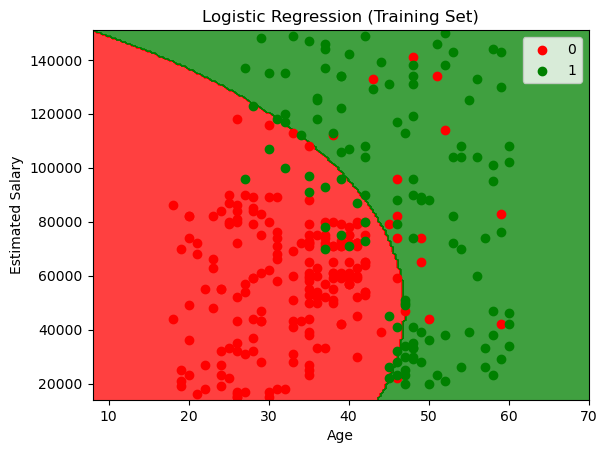

In [10]:
import gc

x_set, y_set = standard_scaler.inverse_transform(x_train), y_train

res = 200 

x1, x2 = np.meshgrid(
    np.linspace(x_set[:, 0].min() - 10, x_set[:, 0].max() + 10, res, dtype=np.float32),
    np.linspace(x_set[:, 1].min() - 1000, x_set[:, 1].max() + 1000, res, dtype=np.float32)
)

predics = classifier.predict(
    standard_scaler.transform(np.array([x1.ravel(), x2.ravel()], dtype=np.float32).T)
).reshape(x1.shape)

plt.contourf(x1, x2, predics, alpha=0.75, cmap=ListedColormap(('red', 'green')))
del x1, x2, predics; gc.collect()  # libera a RAM do grid antes de plotar os pontos

plt.xlim(x_set[:, 0].min() - 10, x_set[:, 0].max() + 10)
plt.ylim(x_set[:, 1].min() - 1000, x_set[:, 1].max() + 1000)

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                c=ListedColormap(('red', 'green'))(i), label=j)

plt.title('Logistic Regression (Training Set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

/tmp/ipykernel_9602/1679666964.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


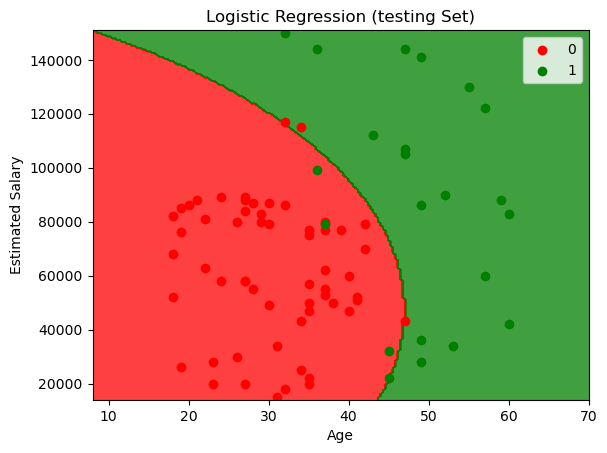

In [11]:

x_set, y_set = standard_scaler.inverse_transform(x_test), y_test

res = 200 

x1, x2 = np.meshgrid(
    np.linspace(x_set[:, 0].min() - 10, x_set[:, 0].max() + 10, res, dtype=np.float32),
    np.linspace(x_set[:, 1].min() - 1000, x_set[:, 1].max() + 1000, res, dtype=np.float32)
)

predics = classifier.predict(
    standard_scaler.transform(np.array([x1.ravel(), x2.ravel()], dtype=np.float32).T)
).reshape(x1.shape)

plt.contourf(x1, x2, predics, alpha=0.75, cmap=ListedColormap(('red', 'green')))
del x1, x2, predics; gc.collect()

plt.xlim(x_set[:, 0].min() - 10, x_set[:, 0].max() + 10)
plt.ylim(x_set[:, 1].min() - 1000, x_set[:, 1].max() + 1000)

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                c=ListedColormap(('red', 'green'))(i), label=j)

plt.title('Logistic Regression (testing Set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()